In [2]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [3]:
X_train_processed = joblib.load(
    "../models/X_train_processed.pkl"
)

X_test_processed = joblib.load(
    "../models/X_test_processed.pkl"
)

y_train = joblib.load(
    "../models/y_train.pkl"
)

y_test = joblib.load(
    "../models/y_test.pkl"
)

In [4]:
preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

In [5]:
lr = LinearRegression()

lr.fit(
    X_train_processed,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
lr_pred = lr.predict(X_test_processed)

In [7]:
def evaluate_model(model_name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    
    rmse = np.sqrt(
        mean_squared_error(y_true, predictions)
    )

    r2 = r2_score(y_true, predictions)

    print(f"Model: {model_name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [8]:
lr_results = evaluate_model("Linear Regression", y_test, lr_pred)

Model: Linear Regression
MAE: 49645.49
RMSE: 69127.04
R2 Score: 0.6353


In [ ]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(
    X_train_processed,
    y_train
)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
dt_pred = dt.predict(X_test_processed)

In [11]:
dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

Model: Decision Tree
MAE: 43092.87
RMSE: 69860.83
R2 Score: 0.6276


In [12]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_processed,
    y_train
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
rf_pred = rf.predict(
    X_test_processed
)

In [ ]:
rf_results = evaluate_model("Random Forest", y_test, rf_pred)

Model: Random Forest
MAE: 31766.87
RMSE: 49499.52
R2 Score: 0.8130


In [15]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb.fit(
    X_train_processed,
    y_train
)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [16]:
gb_pred = gb.predict(
    X_test_processed
)

In [17]:
gb_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred
)

Model: Gradient Boosting
MAE: 33901.16
RMSE: 50437.09
R2 Score: 0.8059


In [18]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(
    X_train_processed,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [19]:
xgb_pred = xgb.predict(
    X_test_processed
)

In [20]:
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

Model: XGBoost
MAE: 28793.66
RMSE: 44064.08
R2 Score: 0.8518


In [21]:
rf_cv_scores = cross_val_score(
    rf,
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2"
)

In [23]:
train_score = rf.score(
    X_train_processed,
    y_train
)

test_score = rf.score(
    X_test_processed,
    y_test
)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.9750294857516959
Test R2: 0.8130200506191368


In [24]:
importance = rf.feature_importances_

In [25]:
feature_names = preprocessor.get_feature_names_out()

In [26]:
feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [27]:
feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

feature_df.head(10)

,Feature,Importance
7,num__median_income,0.481185
12,cat__ocean_proximity_INLAND,0.138438
10,num__population_per_household,0.120916
0,num__longitude,0.057680
1,num__latitude,0.056493
2,num__housing_median_age,0.044269
8,num__rooms_per_household,0.025963
9,num__bedrooms_per_room,0.024478
3,num__total_rooms,0.012750
4,num__total_bedrooms,0.011962


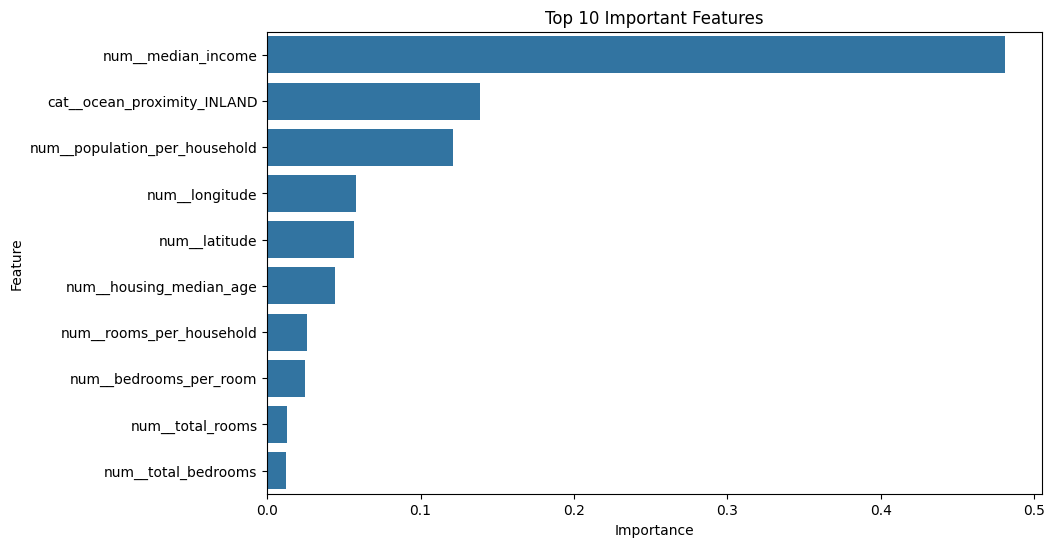

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

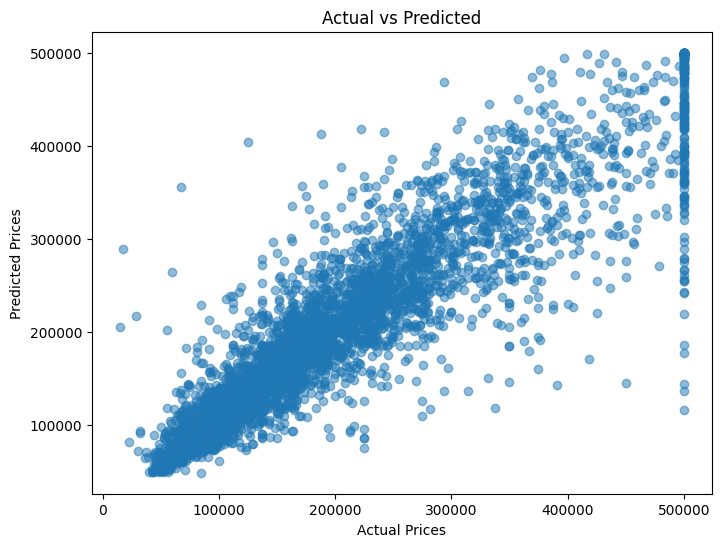

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted")

plt.show()

In [30]:
results_df = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    gb_results,
    xgb_results
])

In [31]:
results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

results_df

,Model,MAE,RMSE,R2
4,XGBoost,28793.657989,44064.077133,0.851829
2,Random Forest,31766.872613,49499.515596,0.813020
3,Gradient Boosting,33901.157924,50437.089012,0.805870
0,Linear Regression,49645.492445,69127.038299,0.635339
1,Decision Tree,43092.870882,69860.829326,0.627556


In [32]:
best_model = xgb

In [33]:
joblib.dump(
    best_model,
    "../models/final_model.pkl"
)

['../models/final_model.pkl']

Key Modeling Findings:

1. Linear Regression established baseline performance.

2. Decision Tree showed strong overfitting.

3. Random Forest significantly improved prediction accuracy.

4. Gradient Boosting improved nonlinear learning.

5. XGBoost achieved highest overall performance.

6. Cross validation confirmed model stability.

7. median_income was the most influential feature.

8. Ensemble methods outperformed simple linear models.
